In [1]:
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from morenita_style import use_morenita, title, sign, highlight

p = use_morenita("paper")   # soft cream + logo gold, every chart from here on

df = pd.read_parquet("/Users/amelia/Desktop/Morenita Signals/data/clean/clean.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3137 entries, 0 to 3136
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   author_name         2973 non-null   object
 1   edition_count       3137 non-null   int64 
 2   first_publish_year  3137 non-null   int64 
 3   key                 3137 non-null   object
 4   language            3042 non-null   object
 5   title               3137 non-null   object
 6   subject             3137 non-null   object
dtypes: int64(2), object(5)
memory usage: 171.7+ KB


In [2]:
# How many duplicates do we have?
df.duplicated(subset=["key"]).sum()

np.int64(7)

In [3]:
# What does the data actually look like?
df.head(10)

,author_name,edition_count,first_publish_year,key,language,title,subject
0,John Berger,17,1972,/works/OL1980231W,eng,Ways of Seeing,"[Art, Art appreciation, Technique, Nonfiction,..."
1,E. H. Gombrich,20,1960,/works/OL686192W,eng,Art and illusion,"[Visual perception, Art, Psychology, Compositi..."
2,Donis A. Dondis,3,1973,/works/OL7139504W,und,A primer of visual literacy,"[Visual perception, Technique, Art, Compositio..."
3,Rudolf Arnheim,17,1954,/works/OL980214W,eng,Art and visual perception,"[Psychology, Art, Visual perception, Artists, ..."
4,Edmund Burke Feldman,15,1971,/works/OL2913728W,eng,Varieties of visual experience,"[Art, Psychology, Composition (Art), Visual pe..."
5,Paul Zelanski,7,1987,/works/OL2561067W,eng,Shaping space,"[Design, Visual perception, Space (Art), Relie..."
6,Charles Wallschlaeger,1,1992,/works/OL4490310W,eng,Basic visual concepts and principles for artis...,"[Symmetry (Art), Proportion (Art), Perspective..."
7,Patrick Frank,11,2005,/works/OL1818141W,eng,Prebles' artforms,"[Visual perception, Composition (Art), Art, Hi..."
8,John Berger,9,1980,/works/OL1980225W,eng,About Looking,"[Art, Visual perception, Psychology, Meaning (..."
9,Patrick Frank,4,2008,/works/OL15633383W,eng,Prebles' artforms,"[Visual perception, Composition (Art), Art, Hi..."


In [4]:
# Basic statistics on the number columns 
df.describe()

,edition_count,first_publish_year
count,3137.000000,3137.000000
mean,13.844756,1962.791839
std,104.399356,151.215392
min,0.000000,0.000000
25%,1.000000,1974.000000
50%,3.000000,1998.000000
75%,6.000000,2009.000000
max,3198.000000,2026.000000


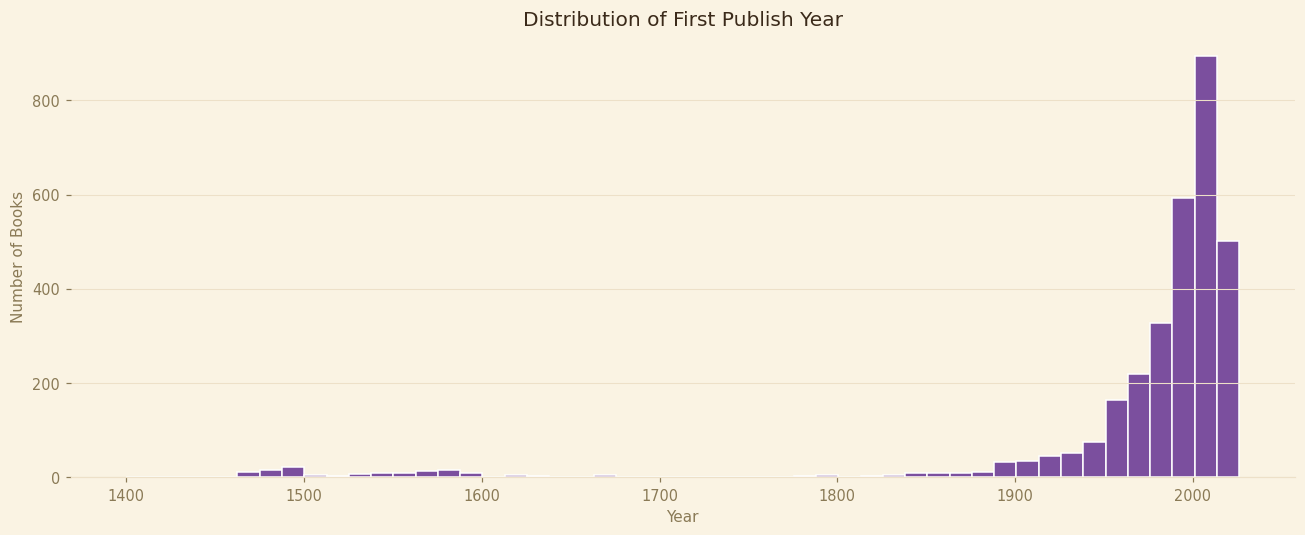

In [5]:
# Drop rows where first_publish_year is 0
df_clean = df[df["first_publish_year"] > 0]

# Plot distribution of publish years
plt.figure(figsize=(12, 5))
plt.hist(df_clean["first_publish_year"], bins=50, color="#7B4F9E", edgecolor="white")
plt.title("Distribution of First Publish Year")
plt.xlabel("Year")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.show()

In [6]:
# explode turns each item in a list into its own row
subjects_exploded = df.explode("subject")
subjects_exploded["subject"].value_counts().head(20)

subject
History and criticism                   495
Indigenous peoples                      439
Jazz                                    381
Fiction                                 367
Biography                               362
Latin American literature               355
Music                                   350
History                                 334
African Americans                       309
Visual perception                       238
Jazz musicians                          234
Juvenile literature                     229
Medieval and modern Latin literature    169
Visual communication                    167
Art                                     166
American literature                     148
Classical                               132
Genres & Styles - Classical             131
Music/Songbooks                         123
Genres & Styles                         122
Name: count, dtype: int64

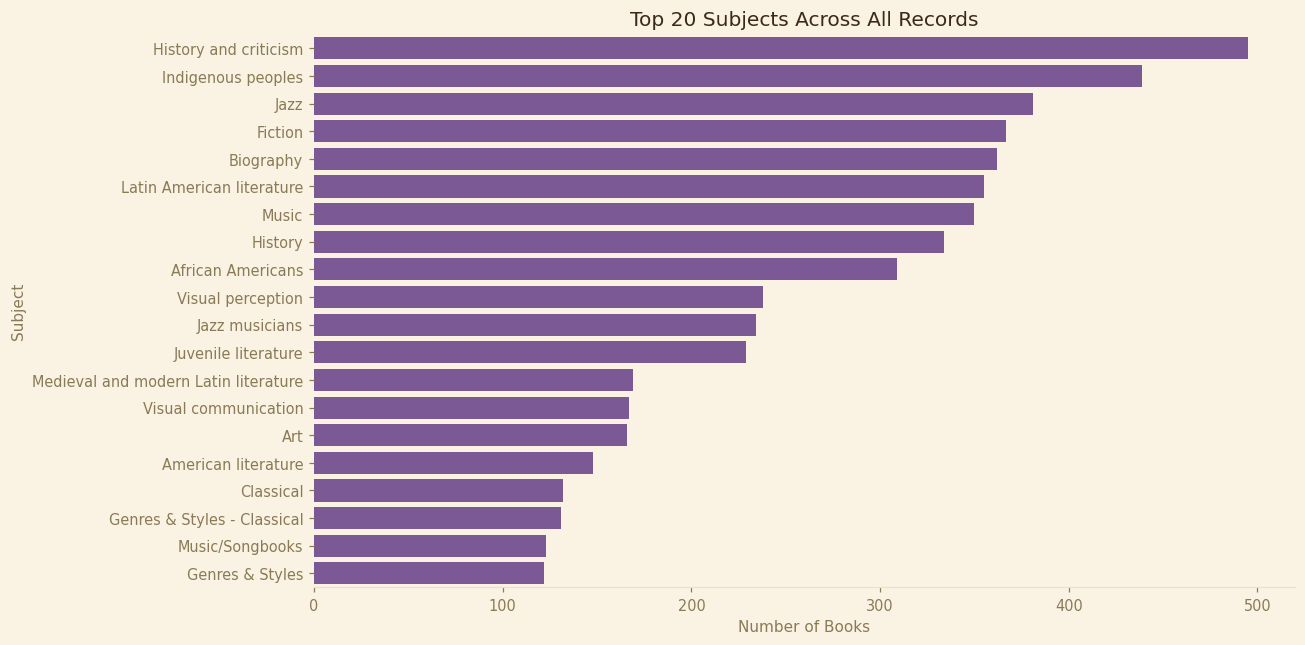

In [7]:
top_subjects = subjects_exploded["subject"].value_counts().head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_subjects.values, y=top_subjects.index, color="#7B4F9E")
plt.title("Top 20 Subjects Across All Records")
plt.xlabel("Number of Books")
plt.ylabel("Subject")
plt.tight_layout()
plt.show()

In [8]:
# How many books per language?
df["language"].value_counts().head(10)

language
eng    2460
spa     222
ger      59
fre      56
lat      30
rus      24
ita      20
und      12
dut      12
tur      12
Name: count, dtype: int64

In [9]:
# What years are most represented per subject?
df_clean.groupby("first_publish_year")["title"].count().sort_values(ascending=False).head(10)

first_publish_year
2006    114
2000     95
2004     83
2007     80
2013     76
2018     74
2005     73
2003     72
2017     71
2014     65
Name: title, dtype: int64

In [10]:
# How many subjects does the average book have?
df["subject"].apply(lambda x: len(x) if hasattr(x, '__len__') else 0).describe()

count    3137.000000
mean        8.884922
std        13.109228
min         1.000000
25%         3.000000
50%         6.000000
75%        10.000000
max       365.000000
Name: subject, dtype: float64

In [11]:
import numpy as np

all_subjects = df["subject"].explode()
print("Unique subjects:", df["subject"].apply(lambda x: list(x) if isinstance(x, np.ndarray) else []).explode().nunique())

Unique subjects: 9219


In [12]:
df["subject"].apply(lambda x: list(x) if isinstance(x, np.ndarray) else []).explode().value_counts().head(20)

subject
History and criticism                   495
Indigenous peoples                      439
Jazz                                    381
Fiction                                 367
Biography                               362
Latin American literature               355
Music                                   350
History                                 334
African Americans                       309
Visual perception                       238
Jazz musicians                          234
Juvenile literature                     229
Medieval and modern Latin literature    169
Visual communication                    167
Art                                     166
American literature                     148
Classical                               132
Genres & Styles - Classical             131
Music/Songbooks                         123
Genres & Styles                         122
Name: count, dtype: int64

## LinkedIn share visuals

Stage 6 — three chart exports built on the real cleaned data + the Stage 4 similarity engine.

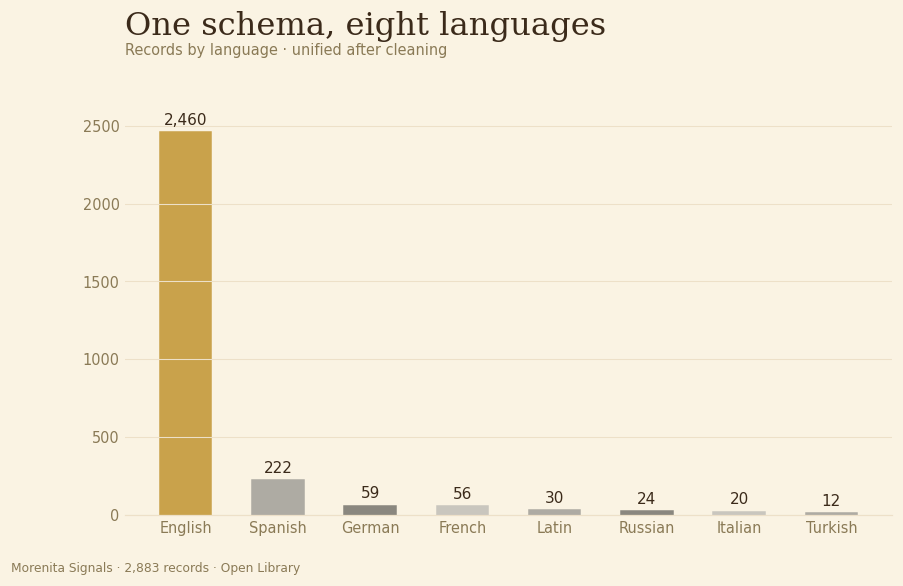

In [13]:
# ── records per language (source-institution breakdown isn't ready yet —
#    Met/MusicBrainz collectors exist in src/collect/ but haven't been merged
#    into clean.parquet, so this uses the real column we do have) ──
lang_names = {
    "eng": "English", "spa": "Spanish", "ger": "German", "fre": "French",
    "lat": "Latin", "rus": "Russian", "ita": "Italian", "dut": "Dutch",
    "tur": "Turkish", "por": "Portuguese",
}
lang_counts = df.loc[df["language"] != "und", "language"].value_counts().head(8)
labels = [lang_names.get(code, code) for code in lang_counts.index]
values = lang_counts.values

fig, ax = plt.subplots(figsize=(9, 5.2))
bars = ax.bar(labels, values, width=0.56)
highlight(ax, bars, 0, "paper")                   # gold on the largest language

for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, v + max(values)*0.02,
            f"{v:,}", ha="center", fontsize=10, color=p["ink"])

title(ax, "One schema, eight languages",
      "Records by language · unified after cleaning", "paper")
ax.set_ylim(0, max(values)*1.15)
ax.tick_params(length=0)
sign(fig, f"Morenita Signals · {values.sum():,} records · Open Library", "paper")
fig.savefig("signals_languages.png", dpi=200, bbox_inches="tight")
plt.show()

In [14]:
# ── build the similarity engine (mirrors src/model/recommender.py, inline
#    here so the notebook can chart it) ──
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

df_sim = df.reset_index(drop=True)
subject_str = df_sim["subject"].apply(lambda x: " ".join(x) if hasattr(x, "__iter__") else "")
tfidf_matrix = TfidfVectorizer().fit_transform(subject_str)
sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
titles = df_sim["title"].tolist()
sim.shape

(3137, 3137)

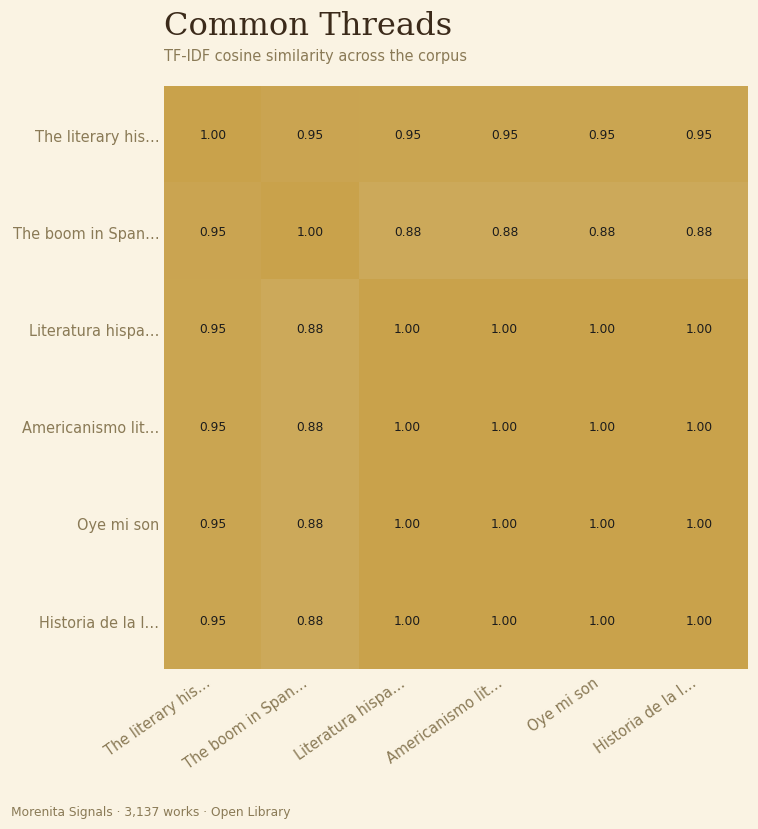

In [15]:
# ── one seed work + its top-5 nearest neighbors by cosine similarity —
#    a real 6-item cluster, not hand-picked indices, so off-diagonal
#    values are meaningful ──
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from morenita_style import DISPLAY, BODY

seed = "The literary history of Spanish America"
seed_idx = titles.index(seed)
row = sim[seed_idx].copy()
row[seed_idx] = -1                          # exclude self from the neighbor search
top5 = np.argsort(row)[::-1][:5]
idx = [seed_idx] + top5.tolist()

M = sim[np.ix_(idx, idx)]

def _truncate(s, n=16):
    return s if len(s) <= n else s[:n] + "…"

labels = [_truncate(titles[i]) for i in idx]

fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
fig.get_layout_engine().set(rect=(0, 0.06, 1, 1))   # reserve bottom margin for sign()

cmap = LinearSegmentedColormap.from_list("cream-gold", ["#E8E0CE", p["gold"]])
ax.imshow(M, cmap=cmap, vmin=0, vmax=1, aspect="equal")
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks(range(len(labels)), labels, rotation=35, ha="right")
ax.set_yticks(range(len(labels)), labels)
ax.tick_params(length=0)

for i in range(len(labels)):
    for j in range(len(labels)):
        r, g, b, _ = cmap(M[i, j])
        luminance = 0.299 * r + 0.587 * g + 0.114 * b
        text_color = "#1C1C1C" if luminance > 0.6 else "#F2F0EB"
        ax.text(j, i, f"{M[i,j]:.2f}", ha="center", va="center", fontsize=8,
                color=text_color)

ax.set_title("Common Threads", fontfamily=DISPLAY, fontsize=21,
              color=p["ink"], loc="left", pad=34)
ax.text(0, 1.045, "TF-IDF cosine similarity across the corpus", transform=ax.transAxes,
        fontsize=9.5, color=p["muted"], fontfamily=BODY)

sign(fig, "Morenita Signals · 3,137 works · Open Library", "paper")
fig.savefig("signals_similarity.png", dpi=200, bbox_inches="tight")
plt.show()

In [16]:
# ── recommend() now returns (title, author, score) tuples instead of
#    printing — see src/model/recommender.py ──
import sys
sys.path.append("/Users/amelia/Desktop/Morenita Signals")
from src.model.recommender import recommend

query = "The literary history of Spanish America"   # a query with a great result
results = recommend(query, df_sim, sim, n=5)

print(f"◆ {query}\n")
for i, (title_, author, score) in enumerate(results, 1):
    print(f"  {i}. {title_}  ·  {author}  ·  {score:.3f}")

◆ The literary history of Spanish America

  1. The boom in Spanish American literature  ·  José Donoso  ·  0.950
  2. Americanismo literario  ·  Federico García Godoy  ·  0.949
  3. Historia de la literatura americana en lengua española  ·  Robert Bazin  ·  0.949
  4. Literatura hispanoamericana  ·  Angel Valbuena Briones  ·  0.949
  5. Oye mi son  ·  Roberto González Echevarría  ·  0.949
